# 08 - Comparación de Modelos: RF vs XGBoost

Este notebook compara los dos modelos entrenados: Random Forest y XGBoost.

**Entrada**: `rf_model{suffix}.joblib`, `xgb_model{suffix}.joblib`, `test_embeddings{suffix}.parquet`  
**Salida**: Tabla comparativa, gráficos, recomendaciones

---

**CONFIGURACIÓN**: Este notebook debe coincidir con los notebooks 06-07.

## 2. Baseline: Dummy Classifier

Antes de comparar RF vs XGBoost, establecemos un **punto de referencia mínimo**:
un clasificador que no aprende nada, solo predice siempre la clase más frecuente
(estrategia `most_frequent`).

**Por qué es necesario**: con desbalanceo de clases (joy=38%, sadness=31%,
anger=20%, fear=5%, love=5%), un modelo sin capacidad predictiva puede alcanzar
~38% de accuracy solo prediciendo siempre `joy`. Sin este baseline, no podemos
afirmar con rigor que RF y XGBoost realmente aprenden patrones de los datos.

In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Cargar datos (mismos que usarán RF y XGBoost)
from pathlib import Path
import pandas as pd
import numpy as np

DATA_EMBEDDINGS = Path('../data/embeddings')
USE_SUBSET = False
suffix = '_subset' if USE_SUBSET else ''

train_df = pd.read_parquet(DATA_EMBEDDINGS / f'train_embeddings{suffix}.parquet')
test_df  = pd.read_parquet(DATA_EMBEDDINGS / f'test_embeddings{suffix}.parquet')

X_train = train_df.drop('emotion', axis=1).values
y_train = train_df['emotion'].values
X_test  = test_df.drop('emotion', axis=1).values
y_test  = test_df['emotion'].values

# Dummy: predice siempre la clase más frecuente
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

dummy_acc      = accuracy_score(y_test, y_pred_dummy)
dummy_f1_w     = f1_score(y_test, y_pred_dummy, average='weighted')
dummy_f1_macro = f1_score(y_test, y_pred_dummy, average='macro')

print("=" * 60)
print("BASELINE — DUMMY CLASSIFIER (most_frequent)")
print("=" * 60)
most_frequent_class = dummy.classes_[dummy.class_prior_.argmax()]
print(f"Clase predicha siempre: '{most_frequent_class}'  (clase más frecuente)")
print()
print(f"Accuracy     : {dummy_acc:.4f}")
print(f"F1 weighted  : {dummy_f1_w:.4f}")
print(f"F1 macro     : {dummy_f1_macro:.4f}")
print()
print(classification_report(y_test, y_pred_dummy, digits=4))
print()
print("Interpretación:")
print(f"  Cualquier modelo con F1-macro > {dummy_f1_macro:.4f} supera el baseline.")
print(f"  RF y XGBoost deben superar este umbral para demostrar capacidad predictiva real.")


BASELINE — DUMMY CLASSIFIER (most_frequent)
Clase predicha siempre: 'joy'  (clase más frecuente)

Accuracy     : 0.3829
F1 weighted  : 0.2121
F1 macro     : 0.1108

              precision    recall  f1-score   support

       anger     0.0000    0.0000    0.0000     21936
        fear     0.0000    0.0000    0.0000      5619
         joy     0.3829    1.0000    0.5538     41801
        love     0.0000    0.0000    0.0000      5593
     sadness     0.0000    0.0000    0.0000     34215

    accuracy                         0.3829    109164
   macro avg     0.0766    0.2000    0.1108    109164
weighted avg     0.1466    0.3829    0.2121    109164


Interpretación:
  Cualquier modelo con F1-macro > 0.1108 supera el baseline.
  RF y XGBoost deben superar este umbral para demostrar capacidad predictiva real.


## 1. Importación de Librerías

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import time
import warnings
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✓ Librerías importadas correctamente')

✓ Librerías importadas correctamente


## 2. Configuración

In [20]:
# ============================================================
# CONFIGURACIÓN: Debe coincidir con notebooks 06-07
# ============================================================
USE_SUBSET = False  # True = subset | False = full
# ============================================================

suffix = '_subset' if USE_SUBSET else ''

print('=' * 60)
print('CONFIGURACIÓN DE COMPARACIÓN')
print('=' * 60)
if USE_SUBSET:
    print('✓ Modo: SUBSET (40K train, 10K test)')
else:
    print('✓ Modo: DATASET COMPLETO (436K train, 109K test)')
print('  Comparando: Random Forest vs XGBoost')
print('=' * 60)
print()

CONFIGURACIÓN DE COMPARACIÓN
✓ Modo: DATASET COMPLETO (436K train, 109K test)
  Comparando: Random Forest vs XGBoost



## 3. Configuración de Rutas

In [21]:
DATA_EMBEDDINGS = Path('../data/embeddings')
MODELS_DIR = Path('../models')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('✓ Directorios verificados')

✓ Directorios verificados


## 4. Carga de Test Set

In [22]:
test_emb_path = DATA_EMBEDDINGS / f'test_embeddings{suffix}.parquet'
test_df = pd.read_parquet(test_emb_path)

X_test = test_df.drop('emotion', axis=1).values
y_test = test_df['emotion'].values

print(f'✓ Test embeddings cargados: {test_df.shape}')
print(f'\nDistribución de clases (test):')
print(pd.Series(y_test).value_counts().sort_index())

✓ Test embeddings cargados: (109164, 258)

Distribución de clases (test):
anger      21936
fear        5619
joy        41801
love        5593
sadness    34215
Name: count, dtype: int64


## 5. Carga de Modelos y Generación de Predicciones

In [23]:
print('Cargando modelos...')

rf_model = joblib.load(MODELS_DIR / f'rf_model{suffix}.joblib')
xgb_model = joblib.load(MODELS_DIR / f'xgb_model{suffix}.joblib')

print('✓ Random Forest cargado')
print('✓ XGBoost cargado')
print()

Cargando modelos...
✓ Random Forest cargado
✓ XGBoost cargado



In [24]:
print('Generando predicciones...')
print()

results = {}

# Random Forest
print('[1/2] Random Forest...')
start = time.time()
y_pred_rf = rf_model.predict(X_test)
time_rf = time.time() - start
results['Random Forest'] = {'predictions': y_pred_rf, 'time': time_rf}
print(f'  ✓ Completado en {time_rf:.2f}s')

# XGBoost
print('[2/2] XGBoost...')
start = time.time()
y_pred_xgb_encoded = xgb_model.predict(X_test)
le_xgb = joblib.load(MODELS_DIR / f'xgb_label_encoder{suffix}.joblib')
y_pred_xgb = le_xgb.inverse_transform(y_pred_xgb_encoded)
time_xgb = time.time() - start
results['XGBoost'] = {'predictions': y_pred_xgb, 'time': time_xgb}
print(f'  ✓ Completado en {time_xgb:.2f}s')

print()
print('✓ Todas las predicciones completadas')

Generando predicciones...

[1/2] Random Forest...
  ✓ Completado en 1.19s
[2/2] XGBoost...
  ✓ Completado en 0.22s

✓ Todas las predicciones completadas


## 6. Cálculo de Métricas

In [25]:
metrics_data = []

for model_name, model_results in results.items():
    y_pred = model_results['predictions']
    pred_time = model_results['time']

    accuracy = accuracy_score(y_test, y_pred)
    precision_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall_w = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)

    metrics_data.append({
        'Modelo': model_name,
        'Accuracy': accuracy,
        'Precision (weighted)': precision_w,
        'Recall (weighted)': recall_w,
        'F1 (weighted)': f1_w,
        'F1 (macro)': f1_m,
        'Tiempo predicción (s)': pred_time,
        'Velocidad (pred/s)': len(X_test) / pred_time
    })

metrics_df = pd.DataFrame(metrics_data).set_index('Modelo')
print('✓ Métricas calculadas')

✓ Métricas calculadas


## 7. Tabla Comparativa

In [26]:
print('=' * 80)
print('TABLA COMPARATIVA DE MODELOS')
print('=' * 80)
print()

display_df = metrics_df.copy()
perf_cols = ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1 (weighted)', 'F1 (macro)']
display_df[perf_cols] = display_df[perf_cols].round(4)
display_df[['Tiempo predicción (s)', 'Velocidad (pred/s)']] = display_df[['Tiempo predicción (s)', 'Velocidad (pred/s)']].round(2)

print(display_df.to_string())
print()
print('=' * 80)

TABLA COMPARATIVA DE MODELOS

               Accuracy  Precision (weighted)  Recall (weighted)  F1 (weighted)  F1 (macro)  Tiempo predicción (s)  Velocidad (pred/s)
Modelo                                                                                                                                
Random Forest    0.5746                0.5978             0.5746         0.5615      0.4615                   1.19            91957.19
XGBoost          0.4999                0.5752             0.4999         0.5155      0.4424                   0.22           496911.31



## 8. Ranking de Modelos

In [27]:
print('\nRANKING POR MÉTRICA:')
print()

perf_metrics = ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1 (weighted)', 'F1 (macro)']

for metric in perf_metrics:
    ranked = metrics_df.sort_values(metric, ascending=False)
    print(f'📊 {metric}:')
    for i, (model, value) in enumerate(ranked[metric].items(), 1):
        emoji = '🥇' if i == 1 else '🥈'
        print(f'  {emoji} {model}: {value:.4f}')
    print()

print('⚡ Velocidad de predicción:')
ranked = metrics_df.sort_values('Velocidad (pred/s)', ascending=False)
for i, (model, value) in enumerate(ranked['Velocidad (pred/s)'].items(), 1):
    emoji = '🥇' if i == 1 else '🥈'
    time_val = ranked.loc[model, 'Tiempo predicción (s)']
    print(f'  {emoji} {model}: {value:.0f} pred/s ({time_val:.2f}s total)')
print()


RANKING POR MÉTRICA:

📊 Accuracy:
  🥇 Random Forest: 0.5746
  🥈 XGBoost: 0.4999

📊 Precision (weighted):
  🥇 Random Forest: 0.5978
  🥈 XGBoost: 0.5752

📊 Recall (weighted):
  🥇 Random Forest: 0.5746
  🥈 XGBoost: 0.4999

📊 F1 (weighted):
  🥇 Random Forest: 0.5615
  🥈 XGBoost: 0.5155

📊 F1 (macro):
  🥇 Random Forest: 0.4615
  🥈 XGBoost: 0.4424

⚡ Velocidad de predicción:
  🥇 XGBoost: 496911 pred/s (0.22s total)
  🥈 Random Forest: 91957 pred/s (1.19s total)



## 9. Gráficos Comparativos

✓ Gráfico guardado: ..\results\model_comparison.png


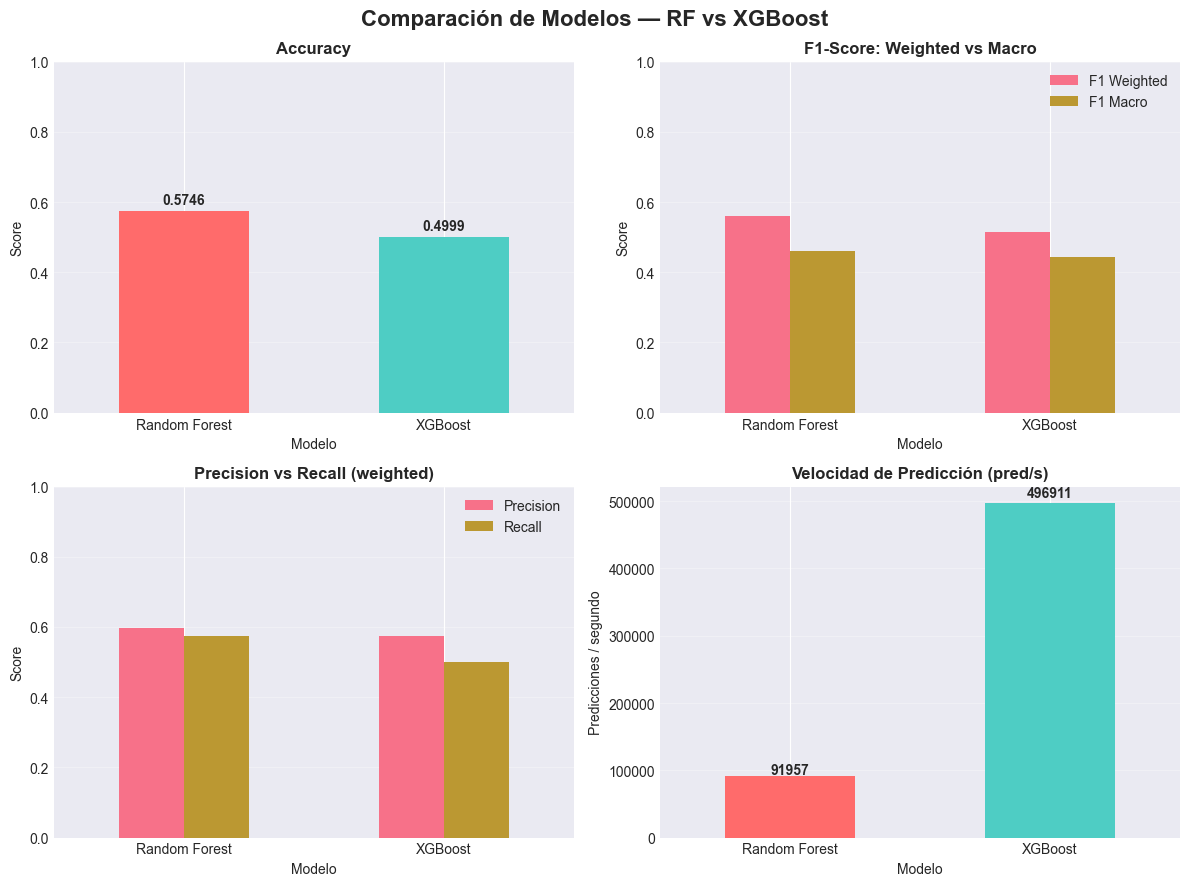

In [ ]:
colors = ['#FF6B6B', '#4ECDC4']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Comparación de Modelos — RF vs XGBoost', fontsize=16, fontweight='bold')

# 1. Accuracy
ax1 = axes[0, 0]
metrics_df['Accuracy'].plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('Accuracy', fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=0)
for i, v in enumerate(metrics_df['Accuracy']):
    ax1.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# 2. F1-Score (weighted vs macro)
ax2 = axes[0, 1]
metrics_df[['F1 (weighted)', 'F1 (macro)']].plot(kind='bar', ax=ax2)
ax2.set_title('F1-Score: Weighted vs Macro', fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=0)
ax2.legend(['F1 Weighted', 'F1 Macro'])

# 3. Precision y Recall
ax3 = axes[1, 0]
metrics_df[['Precision (weighted)', 'Recall (weighted)']].plot(kind='bar', ax=ax3)
ax3.set_title('Precision vs Recall (weighted)', fontweight='bold')
ax3.set_ylabel('Score')
ax3.set_ylim(0, 1)
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', rotation=0)
ax3.legend(['Precision', 'Recall'])

# 4. Velocidad de predicción
ax4 = axes[1, 1]
metrics_df['Velocidad (pred/s)'].plot(kind='bar', ax=ax4, color=colors)
ax4.set_title('Velocidad de Predicción (pred/s)', fontweight='bold')
ax4.set_ylabel('Predicciones / segundo')
ax4.grid(axis='y', alpha=0.3)
ax4.tick_params(axis='x', rotation=0)
for i, v in enumerate(metrics_df['Velocidad (pred/s)']):
    ax4.text(i, v * 1.02, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Análisis por Clase

In [29]:
print('=' * 80)
print('ANÁLISIS DE PERFORMANCE POR CLASE')
print('=' * 80)
print()

classes = sorted(test_df['emotion'].unique())
class_f1_data = []

for model_name, model_results in results.items():
    y_pred = model_results['predictions']
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    for cls in classes:
        if cls in report:
            class_f1_data.append({
                'Modelo': model_name,
                'Clase': cls,
                'F1-Score': report[cls]['f1-score'],
                'Precision': report[cls]['precision'],
                'Recall': report[cls]['recall'],
                'Support': int(report[cls]['support'])
            })

class_f1_df = pd.DataFrame(class_f1_data)
pivot_f1 = class_f1_df.pivot(index='Clase', columns='Modelo', values='F1-Score')
pivot_f1['Mejor Modelo'] = pivot_f1.idxmax(axis=1)
pivot_f1['Máx F1'] = pivot_f1[['Random Forest', 'XGBoost']].max(axis=1)

print('F1-SCORE POR CLASE Y MODELO:')
print()
print(pivot_f1.round(4).to_string())
print()
print('=' * 80)

ANÁLISIS DE PERFORMANCE POR CLASE

F1-SCORE POR CLASE Y MODELO:

Modelo   Random Forest  XGBoost   Mejor Modelo  Máx F1
Clase                                                 
anger           0.5493   0.5496        XGBoost  0.5496
fear            0.2274   0.2818        XGBoost  0.2818
joy             0.6050   0.5175  Random Forest  0.6050
love            0.3145   0.2978  Random Forest  0.3145
sadness         0.6113   0.5652  Random Forest  0.6113



✓ Gráfico guardado: ..\results\f1_by_class.png


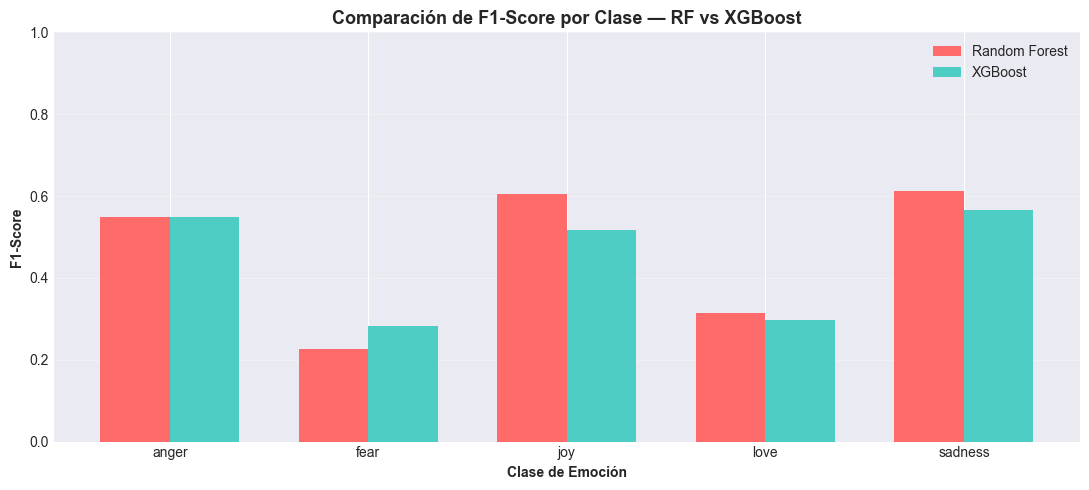

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(classes))
width = 0.35

ax.bar(x - width / 2, pivot_f1['Random Forest'], width, label='Random Forest', color='#FF6B6B')
ax.bar(x + width / 2, pivot_f1['XGBoost'], width, label='XGBoost', color='#4ECDC4')

ax.set_xlabel('Clase de Emoción', fontweight='bold')
ax.set_ylabel('F1-Score', fontweight='bold')
ax.set_title('Comparación de F1-Score por Clase — RF vs XGBoost', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 11. Recomendaciones

In [31]:
print('\n' + '=' * 80)
print('RECOMENDACIONES')
print('=' * 80)
print()

best_accuracy = metrics_df['Accuracy'].idxmax()
best_f1_weighted = metrics_df['F1 (weighted)'].idxmax()
best_f1_macro = metrics_df['F1 (macro)'].idxmax()
best_speed = metrics_df['Velocidad (pred/s)'].idxmax()

print(f'🎯 MEJOR ACCURACY: {best_accuracy} ({metrics_df.loc[best_accuracy, "Accuracy"]:.4f})')
print(f'   → Recomendado si el objetivo es maximizar la tasa de aciertos global')
print()

print(f'🎯 MEJOR F1-WEIGHTED: {best_f1_weighted} ({metrics_df.loc[best_f1_weighted, "F1 (weighted)"]:.4f})')
print(f'   → Recomendado para balance entre precision y recall, considerando desbalanceo')
print()

print(f'🎯 MEJOR F1-MACRO: {best_f1_macro} ({metrics_df.loc[best_f1_macro, "F1 (macro)"]:.4f})')
print(f'   → Recomendado si importa IGUAL la performance en clases minoritarias (fear, love)')
print()

print(f'⚡ MÁS RÁPIDO: {best_speed} ({metrics_df.loc[best_speed, "Velocidad (pred/s)"]:.0f} pred/s)')
print(f'   → Recomendado para sistemas en producción con alta demanda')
print()

print('=' * 80)
print('ANÁLISIS GENERAL:')
print('=' * 80)
print()

if best_accuracy == best_f1_weighted:
    print(f'✅ {best_accuracy} es el ganador claro en accuracy Y F1-weighted')
    print(f'   → Mejor opción para uso general')
else:
    print(f'⚠️  Hay trade-off entre accuracy ({best_accuracy}) y F1-weighted ({best_f1_weighted})')
    print(f'   → Elegir según si importa más la tasa global o el balance precision/recall')

print()

f1_macro_diff = metrics_df['F1 (macro)'].max() - metrics_df['F1 (macro)'].min()
if f1_macro_diff > 0.03:
    print(f'⚠️  Diferencia en F1-macro: {f1_macro_diff:.4f}')
    print(f'   → {best_f1_macro} es mejor para clases minoritarias (fear, love)')
else:
    print(f'✅ Ambos modelos tienen performance similar en clases minoritarias')

print()
print('=' * 80)


RECOMENDACIONES

🎯 MEJOR ACCURACY: Random Forest (0.5746)
   → Recomendado si el objetivo es maximizar la tasa de aciertos global

🎯 MEJOR F1-WEIGHTED: Random Forest (0.5615)
   → Recomendado para balance entre precision y recall, considerando desbalanceo

🎯 MEJOR F1-MACRO: Random Forest (0.4615)
   → Recomendado si importa IGUAL la performance en clases minoritarias (fear, love)

⚡ MÁS RÁPIDO: XGBoost (496911 pred/s)
   → Recomendado para sistemas en producción con alta demanda

ANÁLISIS GENERAL:

✅ Random Forest es el ganador claro en accuracy Y F1-weighted
   → Mejor opción para uso general

✅ Ambos modelos tienen performance similar en clases minoritarias



## 12. Guardar Resultados

In [32]:
# Tabla comparativa
comparison_path = RESULTS_DIR / f'model_comparison{suffix}.csv'
metrics_df.to_csv(comparison_path)
print(f'✓ Tabla comparativa guardada: {comparison_path}')

# F1 por clase
class_f1_path = RESULTS_DIR / f'f1_by_class{suffix}.csv'
class_f1_df.to_csv(class_f1_path, index=False)
print(f'✓ F1 por clase guardado: {class_f1_path}')

# Recomendación en texto
recommendation_path = RESULTS_DIR / f'recommendation{suffix}.txt'
with open(recommendation_path, 'w', encoding='utf-8') as f:
    f.write('=' * 80 + '\n')
    f.write('RESUMEN COMPARATIVO: RF vs XGBoost\n')
    f.write('=' * 80 + '\n\n')
    f.write('MEJOR MODELO POR CRITERIO:\n\n')
    f.write(f'Accuracy:    {best_accuracy} ({metrics_df.loc[best_accuracy, "Accuracy"]:.4f})\n')
    f.write(f'F1-Weighted: {best_f1_weighted} ({metrics_df.loc[best_f1_weighted, "F1 (weighted)"]:.4f})\n')
    f.write(f'F1-Macro:    {best_f1_macro} ({metrics_df.loc[best_f1_macro, "F1 (macro)"]:.4f})\n')
    f.write(f'Velocidad:   {best_speed} ({metrics_df.loc[best_speed, "Velocidad (pred/s)"]:.0f} pred/s)\n\n')
    f.write('TABLA COMPLETA:\n\n')
    f.write(metrics_df.to_string())
    f.write('\n\nF1-SCORE POR CLASE:\n\n')
    f.write(pivot_f1.to_string())
    f.write('\n')

print(f'✓ Recomendación guardada: {recommendation_path}')
print()
print('✅ Comparación completada. Todos los archivos guardados en results/')

✓ Tabla comparativa guardada: ..\results\model_comparison.csv
✓ F1 por clase guardado: ..\results\f1_by_class.csv
✓ Recomendación guardada: ..\results\recommendation.txt

✅ Comparación completada. Todos los archivos guardados en results/


## 13. Comparacion con Threshold Ajustado

Carga los umbrales optimos guardados por los notebooks 06 y 07,
los aplica sobre RF y XGBoost, y compara los **4 escenarios**:
baseline y ajustado para cada modelo.

El ajuste de threshold mejora F1 en `fear` y `love` sin reentrenar.
La optimizacion fue realizada en el notebook de cada modelo (06 y 07).

In [33]:
import json as _json

# --- Cargar umbrales guardados por notebooks 06 y 07 ---
with open(MODELS_DIR / f'rf_thresholds{suffix}.json') as _f:
    _rf_thr_data = _json.load(_f)
with open(MODELS_DIR / f'xgb_thresholds{suffix}.json') as _f:
    _xgb_thr_data = _json.load(_f)

print('Umbrales RF  :', _rf_thr_data['thresholds'])
print('Umbrales XGB :', _xgb_thr_data['thresholds'])
print()

def _apply_thresh(proba, clases, thr_dict):
    thr = np.array([thr_dict[c] for c in clases])
    return clases[(proba / thr).argmax(axis=1)]

# --- RF ---
proba_rf08  = rf_model.predict_proba(X_test)
clases_rf08 = rf_model.classes_
y_pred_rf_adj = _apply_thresh(proba_rf08, clases_rf08, _rf_thr_data['thresholds'])

# --- XGBoost ---
proba_xgb08  = xgb_model.predict_proba(X_test)
clases_xgb08 = le_xgb.classes_
y_pred_xgb_adj = _apply_thresh(proba_xgb08, clases_xgb08, _xgb_thr_data['thresholds'])

print('Predicciones con threshold ajustado generadas.')


Umbrales RF  : {'anger': 0.5, 'fear': 0.3, 'joy': 0.5, 'love': 0.4, 'sadness': 0.5}
Umbrales XGB : {'anger': 0.5, 'fear': 0.5, 'joy': 0.5, 'love': 0.5, 'sadness': 0.5}

Predicciones con threshold ajustado generadas.


In [34]:
# --- Tabla comparativa 4 escenarios ---
_scenarios = [
    ('RF baseline',       y_pred_rf),
    ('RF + threshold',    y_pred_rf_adj),
    ('XGBoost baseline',  y_pred_xgb),
    ('XGBoost + thr',     y_pred_xgb_adj),
]

_rows = []
for _name, _yp in _scenarios:
    _acc = accuracy_score(y_test, _yp)
    _f1w = f1_score(y_test, _yp, average='weighted', zero_division=0)
    _f1m = f1_score(y_test, _yp, average='macro',    zero_division=0)
    _rows.append({'Escenario': _name, 'Accuracy': _acc, 'F1 weighted': _f1w, 'F1 macro': _f1m})

_cmp = pd.DataFrame(_rows).set_index('Escenario')
print('=' * 70)
print('COMPARACION 4 ESCENARIOS')
print('=' * 70)
print(_cmp.round(4).to_string())
print()

# Delta threshold vs baseline por modelo
print('MEJORA por ajuste de threshold:')
_delta_rf  = _cmp.loc['RF + threshold',   'F1 macro'] - _cmp.loc['RF baseline',      'F1 macro']
_delta_xgb = _cmp.loc['XGBoost + thr',    'F1 macro'] - _cmp.loc['XGBoost baseline', 'F1 macro']
print(f'  RF       F1-macro  {_delta_rf:+.4f}')
print(f'  XGBoost  F1-macro  {_delta_xgb:+.4f}')
print()

# F1 por clase — todos los escenarios
print('F1 POR CLASE:')
_header = f'{"Clase":<12}' + ''.join(f'{n:>20}' for n, _ in _scenarios)
print(_header)
for _cls in sorted(rf_model.classes_):
    _line = f'{_cls:<12}'
    for _, _yp in _scenarios:
        _r = classification_report(y_test, _yp, output_dict=True, zero_division=0)
        _line += f'{_r[_cls]["f1-score"]:>20.4f}'
    print(_line)


COMPARACION 4 ESCENARIOS
                  Accuracy  F1 weighted  F1 macro
Escenario                                        
RF baseline         0.5746       0.5615    0.4615
RF + threshold      0.5669       0.5633    0.4826
XGBoost baseline    0.4999       0.5155    0.4424
XGBoost + thr       0.4999       0.5155    0.4424

MEJORA por ajuste de threshold:
  RF       F1-macro  +0.0211
  XGBoost  F1-macro  +0.0000

F1 POR CLASE:
Clase                RF baseline      RF + threshold    XGBoost baseline       XGBoost + thr
anger                     0.5493              0.5480              0.5496              0.5496
fear                      0.2274              0.3091              0.2818              0.2818
joy                       0.6050              0.5974              0.5175              0.5175
love                      0.3145              0.3507              0.2978              0.2978
sadness                   0.6113              0.6080              0.5652              0.5652


## Resumen

Este notebook compara los dos modelos entrenados:
- **Random Forest**: Modelo ensemble basado en árboles de decisión con `class_weight='balanced'`
- **XGBoost**: Gradient boosting optimizado con `sample_weight` balanceado

**Archivos generados**:
- `results/model_comparison{suffix}.csv`: Tabla comparativa de métricas
- `results/model_comparison{suffix}.png`: Gráficos comparativos
- `results/f1_by_class{suffix}.csv`: F1-score por clase y modelo
- `results/f1_by_class{suffix}.png`: Gráfico de F1 por clase
- `results/recommendation{suffix}.txt`: Recomendación final

**Conclusión**: Ver sección 11 (Recomendaciones) para el mejor modelo según criterio.